Columns: ['Unnamed: 0', 'job_title', 'job_type', 'experience_level', 'location', 'salary_currency', 'salary']
   Unnamed: 0       job_title   job_type experience_level       location  \
0           0  Data scientist  Full Time           Senior  New York City   
1           2  Data scientist  Full Time           Senior         Boston   
2           3  Data scientist  Full Time           Senior         London   
3           4  Data scientist  Full Time           Senior         Boston   
4           5  Data scientist  Full Time           Senior  New York City   

  salary_currency  salary  
0             USD  149000  
1             USD  120000  
2             USD   68000  
3             USD  120000  
4             USD  149000  
Explained variance ratio: [0.0082687  0.00630374]
  experience_level          mean   median
0            Entry  36111.111111  30000.0
1        Executive  76076.923077  46000.0
2              Mid  51786.885246  51000.0
3           Senior  75088.033012  68000.0


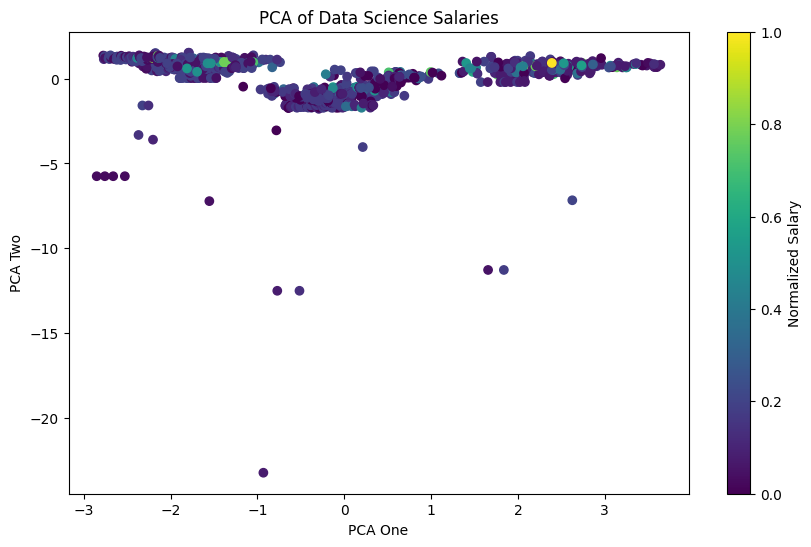

In [2]:
# Use datascience_salaries.csv dataset to perform the following tasks:
# Normalize the ‘salary’ column using Min-Max normalization which scales all salary values between 0 and 1.
# Implement dimensionality reduction like Principal Component Analysis (PCA) or t-SNE to reduce the number of features (columns) in the dataset.
# Group the dataset by the ‘experience_level’ column and calculate the average and median salary for each experience level (e.g., Junior, Mid-level, Senior).

import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('datascience_salaries.csv')
print("Columns:", df.columns.tolist())
print(df.head())

# --- 1. Min-Max normalize the salary column ---
scaler = MinMaxScaler()
df['normalized_salary'] = scaler.fit_transform(df[['salary']])

# --- 2. PCA for dimensionality reduction ---
# PCA only accepts numeric input. The raw dataframe has string columns
# (job_title, experience_level, employment_type, company_location, ...),
# so we one-hot encode them first. We also drop 'salary' (and its normalized copy)
# to avoid leaking the target into the components.
features = df.drop(columns=['salary', 'normalized_salary', 'experience_level'])
features_encoded = pd.get_dummies(features, drop_first=True)

# Standardize before PCA so high-variance columns don't dominate the components.
features_scaled = StandardScaler().fit_transform(features_encoded)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(features_scaled)
df['pca_one'] = pca_result[:, 0]
df['pca_two'] = pca_result[:, 1]
print("Explained variance ratio:", pca.explained_variance_ratio_)

# --- 3. Average and median salary per experience level ---
grouped = df.groupby('experience_level')['salary'].agg(['mean', 'median']).reset_index()
print(grouped)

# --- Visualize PCA results, coloured by normalized salary ---
plt.figure(figsize=(10, 6))
plt.scatter(df['pca_one'], df['pca_two'], c=df['normalized_salary'], cmap='viridis')
plt.colorbar(label='Normalized Salary')
plt.xlabel('PCA One')
plt.ylabel('PCA Two')
plt.title('PCA of Data Science Salaries')
plt.show()
